# Abordagem Híbrida: Métodos Exatos + Algoritmo Genético

Este notebook implementa a seleção híbrida de meta-features combinando
soluções dos métodos exatos (MILP, Knapsack, Correlação Penalizada) com
o Algoritmo Genético via **Seeded GA** — as soluções exatas são injetadas
como indivíduos elite na população inicial do AG.

**Condições avaliadas:**
1. `all meta features` — baseline com todas as features
2. `exact-only` — apenas métodos exatos
3. `GA-only` — apenas algoritmo genético
4. `hybrid` — AG semeado com soluções exatas

## Importação das Bibliotecas
---

In [2]:
import sys
from pathlib import Path

diretorio_atual = Path.cwd()

pasta_src = diretorio_atual / "article" / "src"

if str(pasta_src) not in sys.path:
    sys.path.append(str(pasta_src))

from metamodel import MetaModel
from genetic_selector import GeneticFeatureSelector
from ga_common import GAConfig, Score, GAResult
from hybrid_selector import (
    features_to_individual,
    run_exact_methods,
    build_seeds_from_exact,
    run_hybrid_selection,
)

In [3]:
import os
import warnings
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from scipy.stats import wilcoxon, friedmanchisquare

warnings.filterwarnings("ignore")

## Carregamento dos Dados
---

In [4]:
meta_dataset = pd.read_csv("data/metafeatures_dataset_with_best.csv", index_col=0)

classifier_cols = [
    c for c in meta_dataset.columns
    if c in ['DecisionTree', 'SVM', 'KNN', 'LogisticRegression', 'Perceptron', 'MLP']
]
meta_feature_cols = [
    c for c in meta_dataset.columns
    if c not in ['Dataset', 'Best'] + classifier_cols
]

print(f"Datasets: {len(meta_dataset)}")
print(f"Meta-features totais: {len(meta_feature_cols)}")
print(f"Classes: {meta_dataset['Best'].nunique()}")
meta_dataset.head()

Datasets: 94
Meta-features totais: 1146
Classes: 6


,Dataset,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,...,two_itemset.quantiles.2,two_itemset.quantiles.3,two_itemset.quantiles.4,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.727273,0.030303,0.015152,0.000000,0.045455,0.060606,0.045455,0.030303,0.000000,...,NaN,NaN,NaN,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186,LogisticRegression
1,CPMP-2015-runtime-classification_did41919,0.462121,0.219697,0.060606,0.113636,0.083333,0.030303,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.430710,0.497125,0.563630,0.563594,0.493513,0.521905,LogisticRegression
2,CastMetal1_did1447,0.439394,0.265152,0.083333,0.060606,0.045455,0.037879,0.037879,0.000000,0.000000,...,NaN,NaN,NaN,0.807459,0.859441,0.856597,0.663497,0.862378,0.871608,SVM
3,CostaMadre1_did1446,0.378788,0.121212,0.227273,0.128788,0.083333,0.015152,0.000000,0.007576,0.022727,...,NaN,NaN,NaN,0.824181,0.858136,0.861469,0.636554,0.280904,0.871638,SVM
4,Creditability-German-Credit-Data_did46416,0.522727,0.234848,0.090909,0.030303,0.007576,0.037879,0.022727,0.037879,0.007576,...,NaN,NaN,NaN,0.685000,0.648000,0.749000,0.700000,0.611000,0.711000,LogisticRegression


## Definição dos Meta-Modelos (avaliação)
---

Os mesmos meta-modelos usados no notebook de métodos exatos para garantir comparabilidade.

In [5]:
meta_models = {
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "naive_bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "svm": make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42)),
    "knn": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)),
}

## Funções de Avaliação e Salvamento
---

Reutiliza as mesmas funções dos notebooks anteriores.

In [6]:
def save_csv(data: pd.DataFrame, name: str = "test") -> bool:
    """Salva DataFrame em CSV na pasta de resultados híbridos."""
    path = Path("results/abordagens_hybrid")
    path.mkdir(parents=True, exist_ok=True)

    try:
        data.to_csv(str(path) + f"/{name}.csv", index=True)
        return True
    except Exception as e:
        print("[Erro CSV]: ", e)
        return False


def execute_meta_models(meta_dataset, meta_dataset_train, alg="test", method="test"):
    """Avalia todos os meta-modelos com as features selecionadas."""
    if len(meta_dataset_train.columns) <= 2:
        return [alg, 0.0, 0.0, 0.0, 0.0, 0.0, 'None', method, 0, 'None']

    row = [alg]
    best = [0.0, 'nenhum']

    for key, value in meta_models.items():
        metamodel = MetaModel()
        predicts = metamodel.train_and_evaluate_best_metamodel(
            meta_dataset_train=meta_dataset_train,
            meta_dataset=meta_dataset,
            model=value,
        )
        y_pred = list(predicts['Best clf (pred)'])
        y_true = meta_dataset['Best'].values

        metamodel_accuracy = accuracy_score(y_true, y_pred)
        metamodel_f1 = f1_score(y_true, y_pred, average='weighted')

        print(f"### {key} ###")
        print(f"Meta-model Accuracy: {metamodel_accuracy:.2f}")
        print(f"Meta-model F1-score: {metamodel_f1:.2f}")
        print(f"####{len(key) * '#'}####")

        if best[0] <= metamodel_accuracy:
            best[0] = metamodel_accuracy
            best[1] = key

        row.append(metamodel_accuracy)
        del metamodel

    row.append(best[1])
    row.append(method)

    if len(meta_dataset_train) == 0:
        row.append(0)
        row.append("None")
    else:
        selected_metafeatures = [
            col for col in meta_dataset_train.columns
            if col not in ['Dataset', 'Best']
        ]
        row.append(len(selected_metafeatures))
        row.append(", ".join(selected_metafeatures))

    return row

## Pré-processamento para o AG
---

O mesmo pipeline de filtragem usado no notebook de meta-heurística: filtragem não-supervisionada + Mutual Information.

In [7]:
base_config = GAConfig()

feature_cols = list(meta_feature_cols)

missing_features = [col for col in feature_cols if col not in meta_dataset.columns]
if missing_features:
    raise ValueError(f"As seguintes features não existem em meta_dataset: {missing_features}")

if base_config.target_col not in meta_dataset.columns:
    raise ValueError(f"A coluna alvo '{base_config.target_col}' não existe em meta_dataset.")

target_raw = meta_dataset[base_config.target_col].copy()
valid_target_mask = target_raw.notna()
dataset_ga = meta_dataset.loc[valid_target_mask].copy()
target_raw = dataset_ga[base_config.target_col].copy()

class_counts_before = target_raw.value_counts()
valid_classes = class_counts_before[
    class_counts_before >= base_config.min_samples_per_class
].index
rare_classes = class_counts_before[
    class_counts_before < base_config.min_samples_per_class
]
if len(rare_classes) > 0:
    print("Classes removidas por terem poucas amostras:")
    print(rare_classes)
    print("-" * 90)

dataset_ga = dataset_ga[
    dataset_ga[base_config.target_col].isin(valid_classes)
].copy()

X_df = dataset_ga[feature_cols].reset_index(drop=True)
y = dataset_ga[base_config.target_col].reset_index(drop=True)


@dataclass(frozen=True)
class FeatureFilterConfig:
    missing_threshold: float = 0.60
    quasi_constant_threshold: float = 0.98
    correlation_threshold: float = 0.985
    use_correlation_filter: bool = True


filter_config = FeatureFilterConfig()


def column_fingerprint(series):
    values = series.astype("string").fillna("__missing__")
    hashes = pd.util.hash_pandas_object(values, index=False).to_numpy(dtype=np.uint64)
    return hashlib.blake2b(hashes.tobytes(), digest_size=16).hexdigest()


def filter_features_unsupervised(X_df, config):
    X = X_df.copy()
    report = []
    initial_features = X.shape[1]

    # Valores ausentes
    missing_ratio = X.isna().mean()
    cols_high_missing = missing_ratio[missing_ratio > config.missing_threshold].index.tolist()
    X = X.drop(columns=cols_high_missing)
    report.append({"etapa": "Muitos valores ausentes", "removidas": len(cols_high_missing), "restantes": X.shape[1]})

    # Constantes
    nunique = X.nunique(dropna=True)
    cols_constant = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=cols_constant)
    report.append({"etapa": "Constantes", "removidas": len(cols_constant), "restantes": X.shape[1]})

    # Quase constantes
    cols_quasi_constant = []
    for col in X.columns:
        freq = X[col].value_counts(dropna=False, normalize=True)
        if len(freq) > 0 and freq.iloc[0] >= config.quasi_constant_threshold:
            cols_quasi_constant.append(col)
    X = X.drop(columns=cols_quasi_constant)
    report.append({"etapa": "Quase constantes", "removidas": len(cols_quasi_constant), "restantes": X.shape[1]})

    # Duplicadas
    seen = {}
    cols_duplicate = []
    for col in X.columns:
        fp = column_fingerprint(X[col])
        if fp in seen:
            s1 = X[col].astype("string").fillna("__missing__")
            s2 = X[seen[fp]].astype("string").fillna("__missing__")
            if s1.equals(s2):
                cols_duplicate.append(col)
        else:
            seen[fp] = col
    X = X.drop(columns=cols_duplicate)
    report.append({"etapa": "Duplicadas", "removidas": len(cols_duplicate), "restantes": X.shape[1]})

    # Alta correlação
    cols_correlated = []
    if config.use_correlation_filter:
        numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
        if len(numeric_cols) > 1:
            X_num = X[numeric_cols].copy()
            X_num = X_num.apply(pd.to_numeric, errors="coerce")
            X_num = X_num.fillna(X_num.median(numeric_only=True))
            X_num = X_num.fillna(0)
            corr = X_num.corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            cols_correlated = [col for col in upper.columns if any(upper[col] > config.correlation_threshold)]
            X = X.drop(columns=cols_correlated)
    report.append({"etapa": "Alta correlação numérica", "removidas": len(cols_correlated), "restantes": X.shape[1]})

    report_df = pd.DataFrame(report)
    removed_features = list(set(X_df.columns) - set(X.columns))

    summary = {
        "features_iniciais": initial_features,
        "features_finais": X.shape[1],
        "features_removidas": len(removed_features),
        "removed_features": removed_features,
        "report": report_df,
    }

    return X, summary


X_df, filter_summary = filter_features_unsupervised(X_df=X_df, config=filter_config)
feature_cols = list(X_df.columns)
n_total_features = len(feature_cols)

print("Resumo da filtragem inicial:")
print(filter_summary["report"])
print("-" * 90)
print(f"Features antes: {filter_summary['features_iniciais']}")
print(f"Features depois: {filter_summary['features_finais']}")
print(f"Features removidas: {filter_summary['features_removidas']}")

class_counts = y.value_counts()

if y.nunique() < 2:
    raise ValueError("Após remover classes raras, sobrou apenas uma classe em 'Best'.")

min_class_count = int(class_counts.min())
cv_splits = min(base_config.cv_splits, min_class_count)

if cv_splits < 2:
    raise ValueError("Não há amostras suficientes para validação cruzada.")

cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=base_config.random_state)

print(f"\nCV ajustado para {cv_splits} folds.")
print(f"Features totais: {n_total_features}")
print(f"Amostras usadas: {len(X_df)}")

Classes removidas por terem poucas amostras:
Best
Perceptron    1
Name: count, dtype: int64
------------------------------------------------------------------------------------------
Resumo da filtragem inicial:
                      etapa  removidas  restantes
0   Muitos valores ausentes        120       1026
1                Constantes         32        994
2          Quase constantes          8        986
3                Duplicadas          6        980
4  Alta correlação numérica         88        892
------------------------------------------------------------------------------------------
Features antes: 1146
Features depois: 892
Features removidas: 254

CV ajustado para 5 folds.
Features totais: 892
Amostras usadas: 93


## Ranking de features e filtro supervisionado
---

In [8]:
def compute_feature_ranking(X_df, y, feature_cols, random_state=42):
    rng = np.random.default_rng(random_state)
    scores = np.zeros(len(feature_cols), dtype=float)

    for i, col in enumerate(feature_cols):
        s = X_df[col]
        try:
            if pd.api.types.is_numeric_dtype(s):
                s_num = pd.to_numeric(s, errors="coerce")
                median_value = s_num.median()
                if pd.isna(median_value):
                    median_value = 0.0
                arr = s_num.fillna(median_value).to_numpy().reshape(-1, 1)
                discrete = False
            else:
                arr = (
                    s.astype("string")
                    .fillna("__missing__")
                    .astype("category")
                    .cat.codes
                    .to_numpy()
                    .reshape(-1, 1)
                )
                discrete = True

            score = mutual_info_classif(arr, y, discrete_features=discrete, random_state=random_state)[0]
            scores[i] = 0.0 if np.isnan(score) else score
        except Exception:
            scores[i] = 0.0

    ranking = np.argsort(scores)[::-1]
    if np.all(scores == 0):
        ranking = rng.permutation(len(feature_cols))

    ranking_df = pd.DataFrame({
        "feature": feature_cols,
        "filter_score": scores,
    }).sort_values("filter_score", ascending=False)

    return ranking, scores, ranking_df


feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
    X_df=X_df, y=y, feature_cols=feature_cols, random_state=base_config.random_state
)

# Filtro supervisionado (top-k por MI)
use_supervised_prefilter = True
supervised_top_k = min(150, n_total_features)

if use_supervised_prefilter:
    selected_prefilter_features = feature_ranking_df.head(supervised_top_k)["feature"].tolist()
    X_df = X_df[selected_prefilter_features].copy()
    feature_cols = list(X_df.columns)
    n_total_features = len(feature_cols)

    feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
        X_df=X_df, y=y, feature_cols=feature_cols, random_state=base_config.random_state
    )

    print(f"Filtro supervisionado aplicado. Top-k: {supervised_top_k}")
    print(f"Features restantes: {n_total_features}")
else:
    print("Filtro supervisionado não aplicado.")

feature_ranking_df.head(20)

Filtro supervisionado aplicado. Top-k: 150
Features restantes: 150


,feature,filter_score
0,min.histogram.9,0.327880
1,median.histogram.9,0.327474
2,h_mean.histogram.9,0.324878
3,leaves,0.290867
4,var.histogram.0,0.278510
5,class_conc.histogram.0,0.266457
6,best_node.max,0.263372
7,iq_range.histogram.0,0.259687
8,mad.histogram.0,0.254818
9,elite_nn.median.relative,0.247767


## Pipeline do AG (estimador e construtor de pipeline)
---

In [9]:
base_estimator = ExtraTreesClassifier(
    n_estimators=180,
    max_features="sqrt",
    class_weight="balanced",
    random_state=base_config.random_state,
    n_jobs=1,
)


def build_pipeline():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, make_column_selector(dtype_include=np.number)),
            ("cat", categorical_pipeline, make_column_selector(dtype_exclude=np.number)),
        ],
        remainder="drop",
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(base_estimator)),
    ])

## Etapa 1 — Computar scores das meta-features (para métodos exatos)
---

In [10]:
meta_model_feature_scores = {}

for key, model in meta_models.items():
    meta_model = MetaModel()
    feature_scores = meta_model.meta_feature_scores(meta_dataset=meta_dataset, model=model)
    meta_model_feature_scores[key] = feature_scores

print(f"Scores computados para {len(meta_model_feature_scores)} meta-modelos.")

Scores computados para 5 meta-modelos.


## Etapa 2 — Executar métodos exatos (gerar sementes)
---

In [11]:
exact_results = run_exact_methods(
    meta_dataset=meta_dataset,
    meta_models=meta_models,
    meta_model_feature_scores=meta_model_feature_scores,
    max_feature=200,
    knapsack_lambda=0.002,
    corr_gamma=0.05,
    corr_threshold=0.3,
)

Executando métodos exatos para gerar sementes do AG híbrido

[1/3] Best Subset Selection by Filter MILP...
[2/3] Knapsack Problem ILP...
[3/3] Correlation Penalized MILP...
   -> Otimizando subconjunto para o modelo: decision_tree...
   Concluído! Selecionadas 16 features.
   -> Otimizando subconjunto para o modelo: random_forest...
   Concluído! Selecionadas 111 features.
   -> Otimizando subconjunto para o modelo: naive_bayes...
   Concluído! Selecionadas 0 features.
   -> Otimizando subconjunto para o modelo: svm...
   Concluído! Selecionadas 20 features.
   -> Otimizando subconjunto para o modelo: knn...
   Concluído! Selecionadas 71 features.

----------------------------------------------------------------------
Resumo das sementes geradas:
  Best Subset Selection by Filter MILP | decision_tree: 200 features
  Best Subset Selection by Filter MILP | random_forest: 200 features
  Best Subset Selection by Filter MILP | naive_bayes: 144 features
  Best Subset Selection by Filter MILP

## Etapa 3 — Configurações dos AGs Híbridos
---

Usamos as mesmas 3 configurações do notebook de meta-heurística, agora com sementes dos métodos exatos.

In [12]:
hard_max_features_compact = max(1, min(n_total_features, max(5, n_total_features // 8)))

# AG 1 Híbrido — Clássico binário + sementes exatas
ga_cfg_hybrid_ag1 = GAConfig(
    name="Híbrido AG 1 - Clássico binário",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=4,
    tournament_size=4,
    crossover_rate=0.85,
    mutation_start=0.10,
    mutation_end=0.02,
    init_min_prob=0.08,
    init_max_prob=0.40,
    parsimony_weight=0.04,
    parsimony_power=1.10,
    stability_weight=0.05,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.08,
    hard_max_features=None,
    initialization_strategy="random",
    crossover_mode="one_point",
    mutation_mode="flip",
    use_local_search=False,
    n_jobs=-1,
    random_state=42,
    seed_source="exact_milp_knapsack_corr",
)

# AG 2 Híbrido — Guiado por MI + busca local + sementes exatas
ga_cfg_hybrid_ag2 = GAConfig(
    name="Híbrido AG 2 - Guiado por MI + busca local",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=4,
    tournament_size=4,
    crossover_rate=0.85,
    mutation_start=0.08,
    mutation_end=0.015,
    init_min_prob=0.05,
    init_max_prob=0.30,
    parsimony_weight=0.08,
    parsimony_power=1.25,
    stability_weight=0.10,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.12,
    local_search_rounds=4,
    local_search_add_candidates=25,
    hard_max_features=None,
    initialization_strategy="guided",
    crossover_mode="uniform",
    mutation_mode="remove_bias",
    use_local_search=True,
    n_jobs=-1,
    random_state=42,
    seed_source="exact_milp_knapsack_corr",
)

# AG 3 Híbrido — Compacto/esparso + sementes exatas
ga_cfg_hybrid_ag3 = GAConfig(
    name="Híbrido AG 3 - Compacto/esparso",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=5,
    tournament_size=5,
    crossover_rate=0.90,
    mutation_start=0.10,
    mutation_end=0.01,
    init_min_prob=0.03,
    init_max_prob=0.18,
    parsimony_weight=0.16,
    parsimony_power=1.50,
    stability_weight=0.12,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.15,
    local_search_rounds=5,
    local_search_add_candidates=30,
    hard_max_features=hard_max_features_compact,
    initialization_strategy="guided",
    crossover_mode="uniform",
    mutation_mode="sparse_adaptive",
    use_local_search=True,
    sparse_target_ratio=0.10,
    n_jobs=-1,
    random_state=42,
    seed_source="exact_milp_knapsack_corr",
)

hybrid_configs = [ga_cfg_hybrid_ag1, ga_cfg_hybrid_ag2, ga_cfg_hybrid_ag3]
print(f"Configurações híbridas definidas: {len(hybrid_configs)}")

Configurações híbridas definidas: 3


## Etapa 4 — Executar AG Híbrido (semeado com soluções exatas)
---

In [13]:
hybrid_results = []

for cfg in hybrid_configs:
    print(f"\nExecutando: {cfg.name}")
    result = run_hybrid_selection(
        X_df=X_df,
        y=y,
        feature_cols=feature_cols,
        feature_ranking=feature_ranking,
        pipeline_factory=build_pipeline,
        cv=cv,
        ga_config=cfg,
        exact_results=exact_results,
        n_seeds_per_method=3,
        verbose=True,
    )
    # Treinar modelo final com as features selecionadas
    final_model = build_pipeline()
    final_model.fit(X_df[result.selected_features], y)
    result.model = final_model
    hybrid_results.append(result)
    print(f"{cfg.name} concluído.\n")

print("Todos os AGs híbridos concluídos.")


Executando: Híbrido AG 1 - Clássico binário
AG Híbrido: Híbrido AG 1 - Clássico binário
Total de sementes únicas geradas: 9
Sementes injetadas na população inicial: 9
  Semente 1: 23 features ativas
  Semente 2: 59 features ativas
  Semente 3: 18 features ativas
  Semente 4: 3 features ativas
  Semente 5: 41 features ativas
  Semente 6: 62 features ativas
  Semente 7: 1 features ativas
  Semente 8: 12 features ativas
  Semente 9: 9 features ativas
----------------------------------------------------------------------
Híbrido AG 1 - Clássico binário
População: 80
Gerações máximas: 150
Scoring: accuracy
Inicialização: random
Crossover: one_point
Mutação: flip
Busca local: False
------------------------------------------------------------------------------------------
Geração 000 | Acurácia: 0.56842 ± 0.08331 | Features: 18/150 | Fitness: 0.56037 | Sem melhora: 0/25
Geração 001 | Acurácia: 0.58070 ± 0.03770 | Features: 37/150 | Fitness: 0.57024 | Sem melhora: 0/25
Geração 002 | Acurácia:

c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Geração 031 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 7/25
Geração 032 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 8/25
Geração 033 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 9/25
Geração 034 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 10/25
Geração 035 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 11/25
Geração 036 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 12/25
Geração 037 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 13/25
Geração 038 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 14/25
Geração 039 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora: 15/25
Geração 040 | Acurácia: 0.63450 ± 0.01793 | Features: 55/150 | Fitness: 0.62034 | Sem melhora:

c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Geração 066 | Acurácia: 0.66608 ± 0.10380 | Features: 71/150 | Fitness: 0.64332 | Sem melhora: 24/25
Geração 067 | Acurácia: 0.66608 ± 0.10380 | Features: 71/150 | Fitness: 0.64332 | Sem melhora: 25/25
------------------------------------------------------------------------------------------
Early stopping ativado na geração 67.
------------------------------------------------------------------------------------------
RESULTADO FINAL
Features selecionadas: 71/150
Acurácia estimada: 0.66608 ± 0.10380
Fitness final: 0.64332
Atributos selecionados:
['median.histogram.9', 'h_mean.histogram.9', 'var.histogram.0', 'class_conc.histogram.0', 'best_node.max', 't_mean.histogram.9', 'sparsity.histogram.9', 'worst_node.mean.relative', 'tree_depth.histogram.5', 'range.histogram.0', 'max.histogram.9', 'leaves_homo.histogram.0', 'range.min', 'g_mean.histogram.9', 'random_node.histogram.8.relative', 'elite_nn.min.relative', 'one_nn.min', 'joint_ent.histogram.0', 't4', 'leaves_branch.sd', 'f3.mean', 't

...

Geração 039 | Acurácia: 0.65439 ± 0.07912 | Features: 31/150 | Fitness: 0.63533 | Sem melhora: 22/25
Geração 040 | Acurácia: 0.65439 ± 0.07912 | Features: 31/150 | Fitness: 0.63533 | Sem melhora: 23/25
Geração 041 | Acurácia: 0.65439 ± 0.07912 | Features: 31/150 | Fitness: 0.63533 | Sem melhora: 24/25
Geração 042 | Acurácia: 0.65439 ± 0.07912 | Features: 31/150 | Fitness: 0.63533 | Sem melhora: 25/25
------------------------------------------------------------------------------------------
Early stopping ativado na geração 42.
------------------------------------------------------------------------------------------
Aplicando busca local final...
------------------------------------------------------------------------------------------
RESULTADO FINAL
Features selecionadas: 30/150
Acurácia estimada: 0.66491 ± 0.10846
Fitness final: 0.64337
Atributos selecionados:
['leaves', 't_mean.histogram.9', 'sparsity.histogram.9', 'leaves_corrob.mean', 'max.histogram.9', 'range.min', 'elite_nn.mea

c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Geração 104 | Acurácia: 0.71053 ± 0.10758 | Features: 18/150 | Fitness: 0.69097 | Sem melhora: 4/25
Geração 105 | Acurácia: 0.71053 ± 0.10758 | Features: 18/150 | Fitness: 0.69097 | Sem melhora: 5/25


c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

Geração 106 | Acurácia: 0.71053 ± 0.10758 | Features: 18/150 | Fitness: 0.69097 | Sem melhora: 6/25
Geração 107 | Acurácia: 0.71053 ± 0.10758 | Features: 18/150 | Fitness: 0.69097 | Sem melhora: 7/25
Geração 108 | Acurácia: 0.71053 ± 0.10758 | Features: 18/150 | Fitness: 0.69097 | Sem melhora: 8/25
Geração 109 | Acurácia: 0.71053 ± 0.10758 | Features: 18/150 | Fitness: 0.69097 | Sem melhora: 9/25
Geração 110 | Acurácia: 0.71053 ± 0.10758 | Features: 18/150 | Fitness: 0.69097 | Sem melhora: 10/25
Geração 111 | Acurácia: 0.71053 ± 0.10758 | Features: 18/150 | Fitness: 0.69097 | Sem melhora: 11/25
Geração 112 | Acurácia: 0.71053 ± 0.09541 | Features: 18/150 | Fitness: 0.69243 | Sem melhora: 0/25
Geração 113 | Acurácia: 0.71053 ± 0.09541 | Features: 18/150 | Fitness: 0.69243 | Sem melhora: 1/25
Geração 114 | Acurácia: 0.71053 ± 0.09541 | Features: 18/150 | Fitness: 0.69243 | Sem melhora: 2/25
Geração 115 | Acurácia: 0.71053 ± 0.09541 | Features: 18/150 | Fitness: 0.69243 | Sem melhora: 3/2

## Resultados consolidados dos AGs Híbridos
---

In [14]:
comparison_df = pd.DataFrame([
    {
        "metodo": result.name,
        "accuracy_mean": result.accuracy_mean,
        "accuracy_std": result.accuracy_std,
        "fitness": result.fitness,
        "n_features": result.n_features,
        "percentual_features": result.n_features / n_total_features,
        "features": result.selected_features,
    }
    for result in hybrid_results
]).sort_values(
    by=["accuracy_mean", "fitness", "n_features"],
    ascending=[False, False, True],
).reset_index(drop=True)

comparison_df

,metodo,accuracy_mean,accuracy_std,fitness,n_features,percentual_features,features
0,Híbrido AG 3 - Compacto/esparso,0.710526,0.095413,0.692426,18,0.120000,"[min.histogram.9, h_mean.histogram.9, var.hist..."
1,Híbrido AG 1 - Clássico binário,0.666082,0.103797,0.643323,71,0.473333,"[median.histogram.9, h_mean.histogram.9, var.h..."
2,Híbrido AG 2 - Guiado por MI + busca local,0.664912,0.108457,0.643367,30,0.200000,"[leaves, t_mean.histogram.9, sparsity.histogra..."


In [15]:
# Selecionar o melhor resultado híbrido
best_hybrid = max(
    hybrid_results,
    key=lambda r: (r.accuracy_mean, r.fitness, -r.n_features),
)

print("Melhor resultado híbrido:")
print(best_hybrid.name)
print("-" * 70)
print(f"Acurácia estimada: {best_hybrid.accuracy_mean:.5f} ± {best_hybrid.accuracy_std:.5f}")
print(f"Fitness: {best_hybrid.fitness:.5f}")
print(f"Features selecionadas: {best_hybrid.n_features}/{n_total_features}")
print("-" * 70)
print(best_hybrid.selected_features)

Melhor resultado híbrido:
Híbrido AG 3 - Compacto/esparso
----------------------------------------------------------------------
Acurácia estimada: 0.71053 ± 0.09541
Fitness: 0.69243
Features selecionadas: 18/150
----------------------------------------------------------------------
['min.histogram.9', 'h_mean.histogram.9', 'var.histogram.0', 'class_conc.histogram.0', 'best_node.max', 'mad.histogram.0', 'elite_nn.median.relative', 't_mean.histogram.9', 'worst_node.mean.relative', 'tree_depth.histogram.5', 'range.histogram.0', 'best_node.histogram.6', 'g_mean.histogram.9', 'random_node.histogram.8.relative', 'one_nn.max.relative', 'cov.histogram.0', 'cov.min', 'naive_bayes.histogram.5']


## Gráficos de evolução dos AGs Híbridos
---

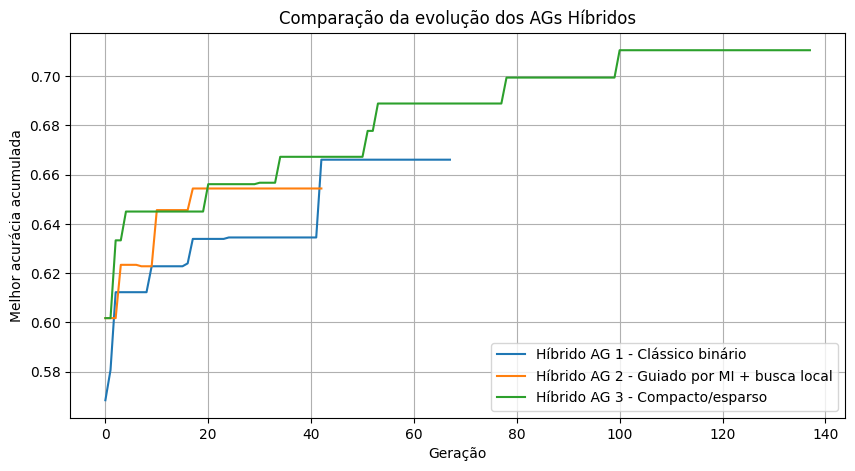

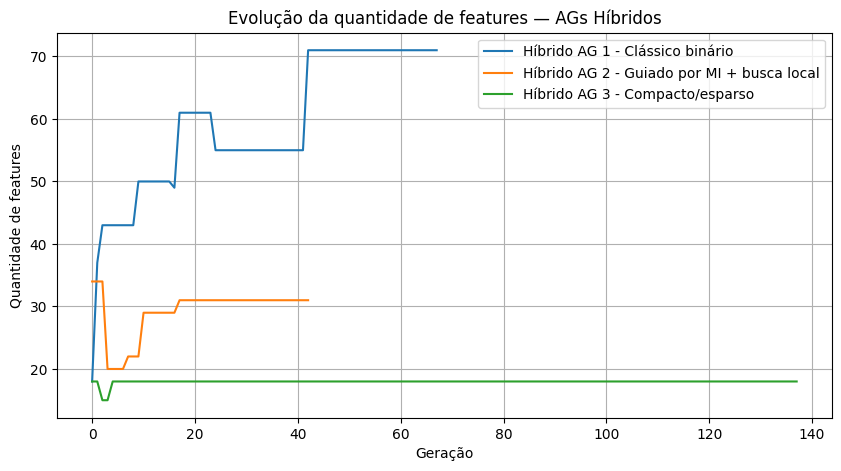

In [16]:
os.makedirs('results/plots', exist_ok=True)

# Evolução da acurácia
fig, ax = plt.subplots(figsize=(10, 5))
for result in hybrid_results:
    ax.plot(result.history["generation"], result.history["accuracy_mean"], label=result.name)
ax.set_xlabel("Geração")
ax.set_ylabel("Melhor acurácia acumulada")
ax.set_title("Comparação da evolução dos AGs Híbridos")
ax.legend()
ax.grid(True)
fig.savefig('results/plots/evolution_hybrid_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# Evolução do número de features
fig, ax = plt.subplots(figsize=(10, 5))
for result in hybrid_results:
    ax.plot(result.history["generation"], result.history["n_features"], label=result.name)
ax.set_xlabel("Geração")
ax.set_ylabel("Quantidade de features")
ax.set_title("Evolução da quantidade de features — AGs Híbridos")
ax.legend()
ax.grid(True)
fig.savefig('results/plots/evolution_hybrid_n_features.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

## Etapa 5 — Avaliação unificada com `execute_meta_models()`
---

Avaliamos quatro condições:
1. **all meta features** — baseline
2. **exact-only** — melhores resultados dos métodos exatos
3. **GA-only** — resultados carregados do notebook GA
4. **hybrid** — resultados do AG semeado

In [17]:
# DataFrame para armazenar todos os resultados
df_results = pd.DataFrame({
    "alg_selected_meta_features": [],
    "decision_tree": [],
    "random_forest": [],
    "naive_bayes": [],
    "svm": [],
    "knn": [],
    "best": [],
    "method": [],
    "n_features": [],
    "features_selected": [],
})

# ─── Condição 1: all meta features (baseline) ───
print("=" * 70)
print("Condição 1: ALL META FEATURES")
print("=" * 70)
df_results.loc[len(df_results)] = execute_meta_models(
    meta_dataset=meta_dataset,
    meta_dataset_train=meta_dataset,
    alg="all meta features",
    method="all meta features",
)

Condição 1: ALL META FEATURES
### decision_tree ###
Meta-model Accuracy: 0.43
Meta-model F1-score: 0.43
#####################
### random_forest ###
Meta-model Accuracy: 0.53
Meta-model F1-score: 0.49
#####################
### naive_bayes ###
Meta-model Accuracy: 0.43
Meta-model F1-score: 0.39
###################
### svm ###
Meta-model Accuracy: 0.54
Meta-model F1-score: 0.48
###########
### knn ###
Meta-model Accuracy: 0.39
Meta-model F1-score: 0.37
###########


In [18]:
# ─── Condição 2: exact-only ───
print("=" * 70)
print("Condição 2: EXACT-ONLY")
print("=" * 70)

for method_name, alg_features in exact_results.items():
    for alg_name, features in alg_features.items():
        print(f"\nAlgoritmo responsável: {alg_name}")
        print(f"Número de meta features selecionadas: {len(features)}")

        meta_dataset_train = meta_dataset[['Dataset', 'Best'] + features].copy()
        df_results.loc[len(df_results)] = execute_meta_models(
            meta_dataset=meta_dataset,
            meta_dataset_train=meta_dataset_train,
            alg=alg_name,
            method=method_name,
        )

Condição 2: EXACT-ONLY

Algoritmo responsável: decision_tree
Número de meta features selecionadas: 200
### decision_tree ###
Meta-model Accuracy: 0.63
Meta-model F1-score: 0.63
#####################
### random_forest ###
Meta-model Accuracy: 0.47
Meta-model F1-score: 0.42
#####################
### naive_bayes ###
Meta-model Accuracy: 0.35
Meta-model F1-score: 0.35
###################
### svm ###
Meta-model Accuracy: 0.45
Meta-model F1-score: 0.36
###########
### knn ###
Meta-model Accuracy: 0.44
Meta-model F1-score: 0.42
###########

Algoritmo responsável: random_forest
Número de meta features selecionadas: 200
### decision_tree ###
Meta-model Accuracy: 0.44
Meta-model F1-score: 0.43
#####################
### random_forest ###
Meta-model Accuracy: 0.51
Meta-model F1-score: 0.48
#####################
### naive_bayes ###
Meta-model Accuracy: 0.43
Meta-model F1-score: 0.43
###################
### svm ###
Meta-model Accuracy: 0.54
Meta-model F1-score: 0.47
###########
### knn ###
Meta-mode

In [19]:
# ─── Condição 3: GA-only (resultados existentes) ───
print("=" * 70)
print("Condição 3: GA-ONLY (resultados carregados)")
print("=" * 70)

ga_comparison_path = Path("results/abordagens_meta_heuristica/comparacao_algoritmos_geneticos_features.csv")

if ga_comparison_path.exists():
    ga_comparison = pd.read_csv(ga_comparison_path)

    # Pegar o melhor resultado do AG (maior accuracy_mean)
    best_ga_row = ga_comparison.sort_values("accuracy_mean", ascending=False).iloc[0]

    # Extrair features — formato é string de lista Python
    import ast
    ga_features = ast.literal_eval(best_ga_row['features'])

    # Filtrar apenas features existentes no meta_dataset
    ga_features_valid = [f for f in ga_features if f in meta_dataset.columns]

    if len(ga_features_valid) > 0:
        meta_dataset_train_ga = meta_dataset[['Dataset', 'Best'] + ga_features_valid].copy()
        df_results.loc[len(df_results)] = execute_meta_models(
            meta_dataset=meta_dataset,
            meta_dataset_train=meta_dataset_train_ga,
            alg=best_ga_row['metodo'],
            method="GA-only (melhor)",
        )
        print(f"Melhor AG: {best_ga_row['metodo']} ({len(ga_features_valid)} features)")
    else:
        print("Nenhuma feature do GA encontrada no meta_dataset.")
else:
    print("Resultados do GA não encontrados. Execute o notebook de meta-heurística primeiro.")

Condição 3: GA-ONLY (resultados carregados)
### decision_tree ###
Meta-model Accuracy: 0.28
Meta-model F1-score: 0.27
#####################
### random_forest ###
Meta-model Accuracy: 0.59
Meta-model F1-score: 0.56
#####################
### naive_bayes ###
Meta-model Accuracy: 0.52
Meta-model F1-score: 0.53
###################
### svm ###
Meta-model Accuracy: 0.54
Meta-model F1-score: 0.49
###########
### knn ###
Meta-model Accuracy: 0.44
Meta-model F1-score: 0.44
###########
Melhor AG: AG 2 - Guiado por MI + busca local (42 features)


In [20]:
# ─── Condição 4: hybrid (AG semeado com exatos) ───
print("=" * 70)
print("Condição 4: HYBRID (AG semeado)")
print("=" * 70)

for result in hybrid_results:
    print(f"\nAG Híbrido: {result.name}")
    print(f"Features selecionadas: {result.n_features}")

    # Filtrar apenas features presentes no meta_dataset original
    hybrid_features = [f for f in result.selected_features if f in meta_dataset.columns]

    if len(hybrid_features) > 0:
        meta_dataset_train_hybrid = meta_dataset[['Dataset', 'Best'] + hybrid_features].copy()
        df_results.loc[len(df_results)] = execute_meta_models(
            meta_dataset=meta_dataset,
            meta_dataset_train=meta_dataset_train_hybrid,
            alg=result.name,
            method=f"Hybrid Seeded GA",
        )
    else:
        print(f"  ⚠ Nenhuma feature encontrada no meta_dataset.")

Condição 4: HYBRID (AG semeado)

AG Híbrido: Híbrido AG 1 - Clássico binário
Features selecionadas: 71
### decision_tree ###
Meta-model Accuracy: 0.35
Meta-model F1-score: 0.35
#####################
### random_forest ###
Meta-model Accuracy: 0.53
Meta-model F1-score: 0.50
#####################
### naive_bayes ###
Meta-model Accuracy: 0.44
Meta-model F1-score: 0.45
###################
### svm ###
Meta-model Accuracy: 0.53
Meta-model F1-score: 0.48
###########
### knn ###
Meta-model Accuracy: 0.43
Meta-model F1-score: 0.43
###########

AG Híbrido: Híbrido AG 2 - Guiado por MI + busca local
Features selecionadas: 30
### decision_tree ###
Meta-model Accuracy: 0.26
Meta-model F1-score: 0.25
#####################
### random_forest ###
Meta-model Accuracy: 0.54
Meta-model F1-score: 0.52
#####################
### naive_bayes ###
Meta-model Accuracy: 0.55
Meta-model F1-score: 0.55
###################
### svm ###
Meta-model Accuracy: 0.56
Meta-model F1-score: 0.51
###########
### knn ###
Meta-mo

In [21]:
# Visualizar todos os resultados
print(f"Total de linhas: {len(df_results)}")
df_results

Total de linhas: 20


,alg_selected_meta_features,decision_tree,random_forest,naive_bayes,svm,knn,best,method,n_features,features_selected
0,all meta features,0.425532,0.531915,0.425532,0.542553,0.393617,svm,all meta features,1152,"attr_conc.histogram.0, attr_conc.histogram.1, ..."
1,decision_tree,0.627660,0.468085,0.351064,0.446809,0.436170,decision_tree,Best Subset Selection by Filter MILP,200,"attr_conc.histogram.0, attr_conc.histogram.1, ..."
2,random_forest,0.436170,0.510638,0.425532,0.542553,0.404255,svm,Best Subset Selection by Filter MILP,200,"attr_ent.histogram.8, attr_ent.max, attr_ent.m..."
3,naive_bayes,0.382979,0.382979,0.234043,0.382979,0.361702,svm,Best Subset Selection by Filter MILP,144,"attr_conc.quantiles, attr_ent.quantiles, best_..."
4,svm,0.276596,0.425532,0.340426,0.457447,0.382979,svm,Best Subset Selection by Filter MILP,200,"attr_conc.histogram.0, attr_conc.histogram.1, ..."
5,knn,0.212766,0.468085,0.414894,0.489362,0.351064,svm,Best Subset Selection by Filter MILP,200,"attr_conc.histogram.5, attr_ent.histogram.8, a..."
6,decision_tree,0.680851,0.510638,0.170213,0.436170,0.340426,decision_tree,Knapsack Problem ILP,23,"attr_conc.mean, attr_conc.sd, attr_ent.max, co..."
7,random_forest,0.404255,0.531915,0.382979,0.542553,0.436170,svm,Knapsack Problem ILP,147,"attr_ent.max, attr_ent.median, best_node.max, ..."
8,naive_bayes,0.361702,0.521277,0.414894,0.574468,0.563830,svm,Knapsack Problem ILP,200,"attr_conc.histogram.2, attr_ent.histogram.0, a..."
9,svm,0.287234,0.425532,0.287234,0.372340,0.361702,random_forest,Knapsack Problem ILP,50,"attr_conc.mean, attr_conc.median, attr_conc.mi..."


## Etapa 6 — Boxplots por método
---

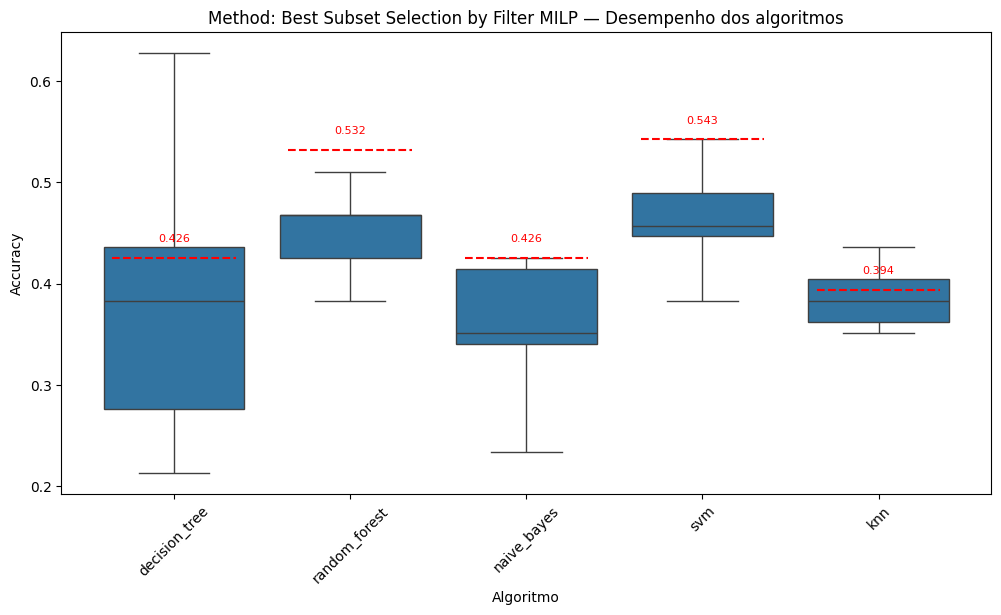

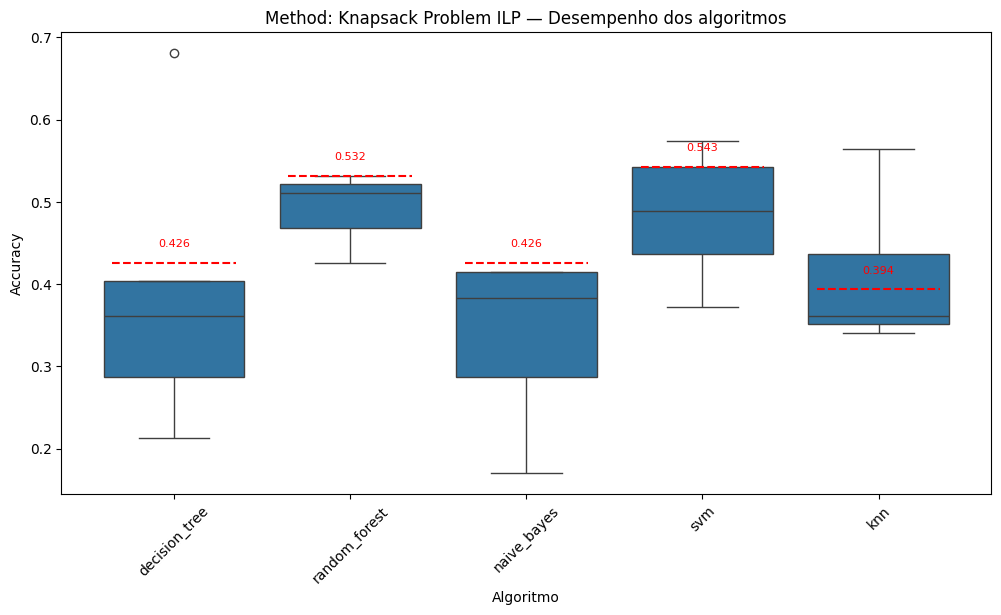

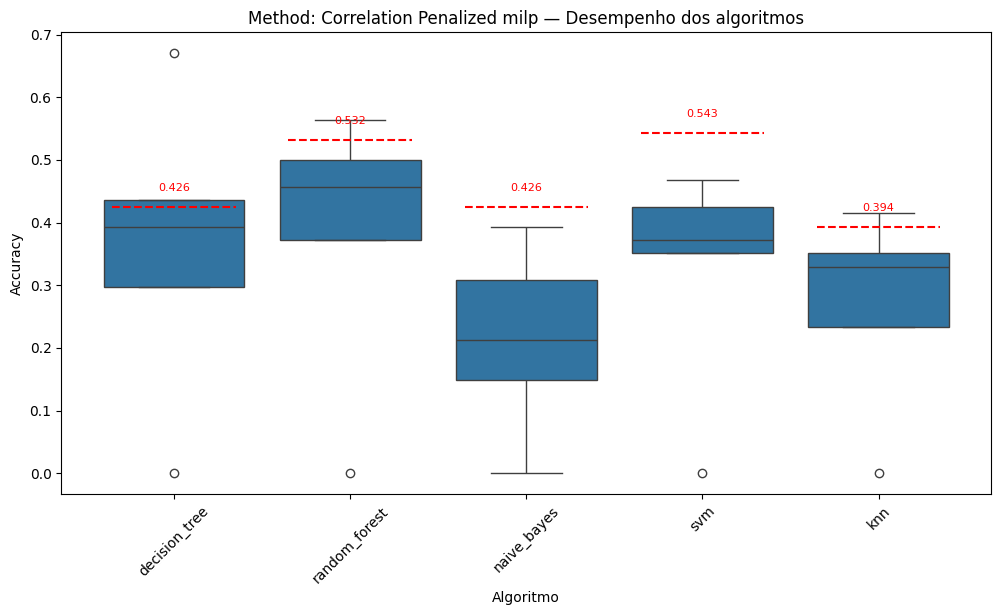

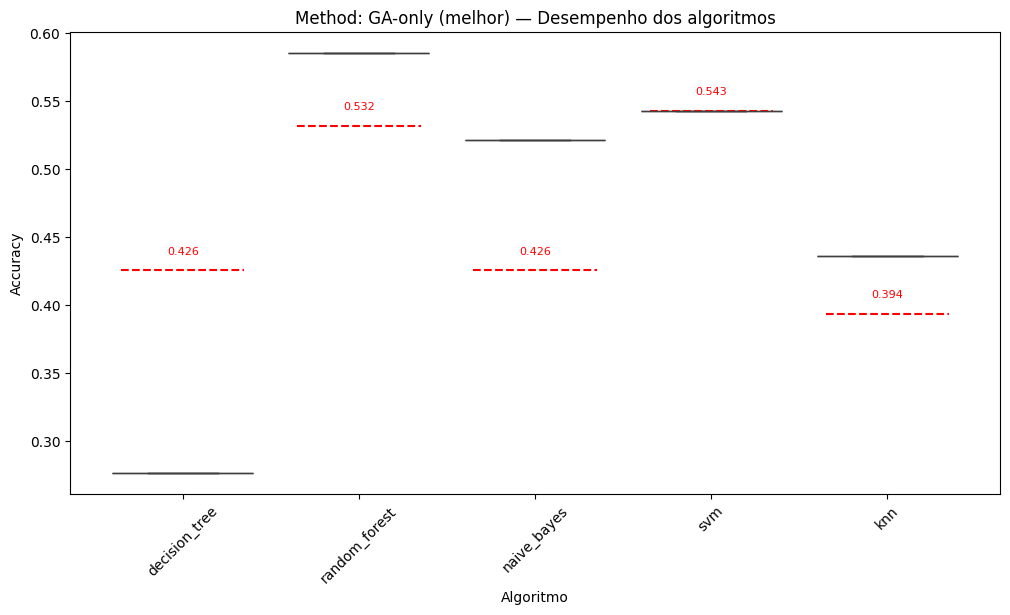

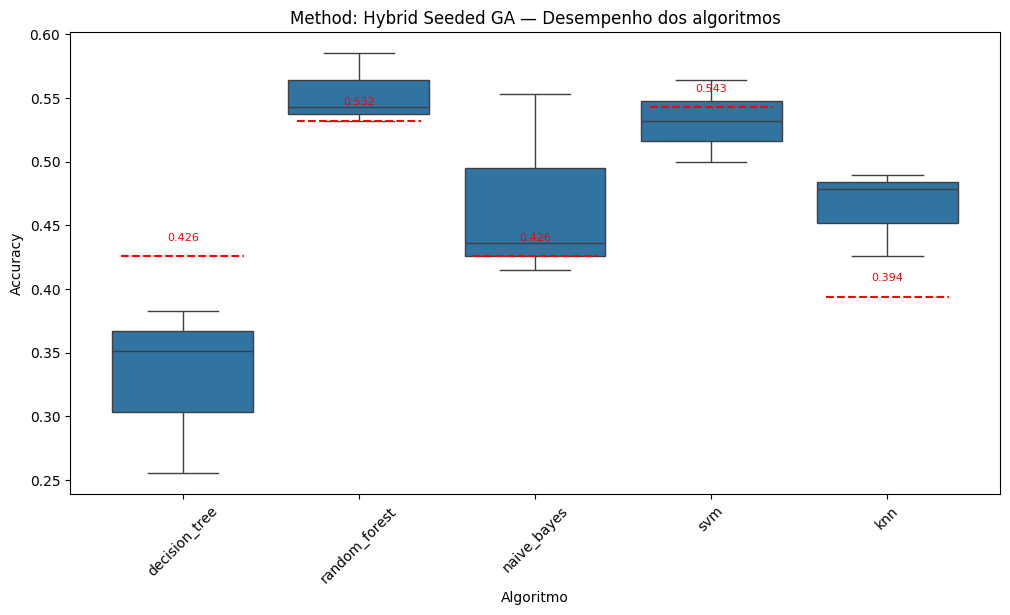

Gráficos gerados em results/plots/


In [22]:
algorithms = ["decision_tree", "random_forest", "naive_bayes", "svm", "knn"]
os.makedirs("results/plots", exist_ok=True)

all_methods = list(df_results['method'].unique())
methods_to_plot = [m for m in all_methods if m != 'all meta features']

# Baseline: média da condição "all meta features"
baseline = {}
for alg in algorithms:
    vals = df_results.loc[df_results['method'] == 'all meta features', alg].dropna()
    baseline[alg] = vals.mean() if len(vals) > 0 else None

for method in methods_to_plot:
    df_sub = df_results[df_results['method'] == method]
    df_melt = df_sub.melt(
        id_vars=['method'], value_vars=algorithms,
        var_name='algorithm', value_name='accuracy',
    )
    df_melt = df_melt.dropna(subset=['accuracy'])

    if df_melt.empty:
        print(f'Nenhum dado para o método {method}, pulando...')
        continue

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(x='algorithm', y='accuracy', data=df_melt, order=algorithms, ax=ax)
    ax.set_title(f'Method: {method} — Desempenho dos algoritmos')
    ax.set_xlabel('Algoritmo')
    ax.set_ylabel('Accuracy')
    ax.tick_params(axis='x', rotation=45)

    y_min, y_max = ax.get_ylim()
    delta = (y_max - y_min) * 0.015 if (y_max > y_min) else 0.001

    for i, alg in enumerate(algorithms):
        b = baseline.get(alg)
        if b is None or np.isnan(b):
            continue
        ax.hlines(y=b, xmin=i - 0.35, xmax=i + 0.35, colors='red', linestyles='--', linewidth=1.5)
        ax.text(i, b + 2 * delta, f'{b:.3f}', ha='center', va='bottom', fontsize=8, color='red')

    safe_name = method.replace(' ', '_').replace('/', '_')
    out_path = f'results/plots/boxplot_method_hybrid_{safe_name}.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('Gráficos gerados em results/plots/')

## Etapa 7 — Tabela de resumo (médias e desvios padrão por condição)
---

In [23]:
# Tabela de resumo por método
summary_rows = []

for method in df_results['method'].unique():
    df_method = df_results[df_results['method'] == method]

    row = {"method": method}
    for alg in algorithms:
        vals = pd.to_numeric(df_method[alg], errors='coerce').dropna()
        if len(vals) > 0:
            row[f"{alg}_mean"] = vals.mean()
            row[f"{alg}_std"] = vals.std()
        else:
            row[f"{alg}_mean"] = np.nan
            row[f"{alg}_std"] = np.nan

    # Média geral entre todos os meta-modelos
    all_means = [row[f"{alg}_mean"] for alg in algorithms if not np.isnan(row.get(f"{alg}_mean", np.nan))]
    row["overall_mean"] = np.mean(all_means) if all_means else np.nan
    row["n_entries"] = len(df_method)

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("overall_mean", ascending=False)
summary_df

,method,decision_tree_mean,decision_tree_std,random_forest_mean,random_forest_std,naive_bayes_mean,naive_bayes_std,svm_mean,svm_std,knn_mean,knn_std,overall_mean,n_entries
4,GA-only (melhor),0.276596,NaN,0.585106,NaN,0.521277,NaN,0.542553,NaN,0.436170,NaN,0.472340,1
5,Hybrid Seeded GA,0.329787,0.066436,0.553191,0.028146,0.468085,0.074468,0.531915,0.031915,0.464539,0.034197,0.469504,3
0,all meta features,0.425532,NaN,0.531915,NaN,0.425532,NaN,0.542553,NaN,0.393617,NaN,0.463830,1
2,Knapsack Problem ILP,0.389362,0.178584,0.491489,0.044120,0.334043,0.105475,0.482979,0.081228,0.410638,0.093532,0.421702,5
1,Best Subset Selection by Filter MILP,0.387234,0.160388,0.451064,0.048518,0.353191,0.076492,0.463830,0.058559,0.387234,0.034142,0.408511,5
3,Correlation Penalized milp,0.359574,0.243220,0.378723,0.222846,0.212766,0.151011,0.323404,0.186489,0.265957,0.162212,0.308085,5


## Etapa 8 — Testes estatísticos
---

**Wilcoxon signed-rank test**: compara `hybrid` vs `all meta features` por algoritmo.

In [24]:
# Comparação estatística: Hybrid vs All Meta Features
print("=" * 70)
print("Testes estatísticos: Hybrid Seeded GA vs All Meta Features")
print("=" * 70)

df_hybrid = df_results[df_results['method'] == 'Hybrid Seeded GA'].copy()
df_all = df_results[df_results['method'] == 'all meta features'].copy()

if len(df_hybrid) > 0 and len(df_all) > 0:
    print(f"\nAmostras Hybrid: {len(df_hybrid)}")
    print(f"Amostras All: {len(df_all)}")

    # Comparar as acurácias médias por algoritmo
    for alg in algorithms:
        hybrid_vals = pd.to_numeric(df_hybrid[alg], errors='coerce').dropna().values
        all_vals = pd.to_numeric(df_all[alg], errors='coerce').dropna().values

        print(f"\n--- {alg} ---")
        print(f"  Hybrid mean: {hybrid_vals.mean():.4f}" if len(hybrid_vals) > 0 else "  Hybrid: sem dados")
        print(f"  All mean:    {all_vals.mean():.4f}" if len(all_vals) > 0 else "  All: sem dados")

        # Wilcoxon requer amostras pareadas e >= 5 pares
        n_pairs = min(len(hybrid_vals), len(all_vals))
        if n_pairs >= 5:
            try:
                stat, p_value = wilcoxon(hybrid_vals[:n_pairs], all_vals[:n_pairs])
                print(f"  Wilcoxon: stat={stat:.4f}, p={p_value:.4f}")
                print(f"  {'Significativo (p < 0.05)' if p_value < 0.05 else 'Não significativo'}")
            except Exception as e:
                print(f"  Wilcoxon não aplicável: {e}")
        else:
            print(f"  Wilcoxon: poucas amostras ({n_pairs} pares, mínimo 5)")

    # Friedman test (se temos >= 3 condições com dados)
    print("\n" + "=" * 70)
    print("Friedman test entre métodos (por algoritmo)")
    print("=" * 70)

    unique_methods = df_results['method'].unique()
    if len(unique_methods) >= 3:
        for alg in algorithms:
            groups = []
            group_names = []
            for method in unique_methods:
                vals = pd.to_numeric(df_results.loc[df_results['method'] == method, alg], errors='coerce').dropna().values
                if len(vals) > 0:
                    groups.append(vals)
                    group_names.append(method)

            if len(groups) >= 3:
                # Friedman requer amostras de mesmo tamanho
                min_len = min(len(g) for g in groups)
                if min_len >= 2:
                    groups_trimmed = [g[:min_len] for g in groups]
                    try:
                        stat, p_value = friedmanchisquare(*groups_trimmed)
                        print(f"\n{alg}: stat={stat:.4f}, p={p_value:.4f} ({'significativo' if p_value < 0.05 else 'não significativo'})")
                    except Exception as e:
                        print(f"\n{alg}: Friedman não aplicável — {e}")
                else:
                    print(f"\n{alg}: poucas amostras para Friedman")
else:
    print("Dados insuficientes para testes estatísticos.")

Testes estatísticos: Hybrid Seeded GA vs All Meta Features

Amostras Hybrid: 3
Amostras All: 1

--- decision_tree ---
  Hybrid mean: 0.3298
  All mean:    0.4255
  Wilcoxon: poucas amostras (1 pares, mínimo 5)

--- random_forest ---
  Hybrid mean: 0.5532
  All mean:    0.5319
  Wilcoxon: poucas amostras (1 pares, mínimo 5)

--- naive_bayes ---
  Hybrid mean: 0.4681
  All mean:    0.4255
  Wilcoxon: poucas amostras (1 pares, mínimo 5)

--- svm ---
  Hybrid mean: 0.5319
  All mean:    0.5426
  Wilcoxon: poucas amostras (1 pares, mínimo 5)

--- knn ---
  Hybrid mean: 0.4645
  All mean:    0.3936
  Wilcoxon: poucas amostras (1 pares, mínimo 5)

Friedman test entre métodos (por algoritmo)

decision_tree: poucas amostras para Friedman

random_forest: poucas amostras para Friedman

naive_bayes: poucas amostras para Friedman

svm: poucas amostras para Friedman

knn: poucas amostras para Friedman


## Etapa 9 — Exportação dos resultados
---

In [25]:
# Salvar CSV principal
if save_csv(data=df_results, name="metafeatures_dataset_with_best"):
    print("OK! CSV de resultados criado com sucesso!")
else:
    print("Erro ao salvar CSV de resultados.")

# Salvar tabela de resumo
if save_csv(data=summary_df, name="summary_comparison"):
    print("OK! CSV de resumo criado com sucesso!")
else:
    print("Erro ao salvar CSV de resumo.")

# Salvar comparação dos AGs híbridos
results_path = Path("results/abordagens_hybrid")
results_path.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(str(results_path / "comparacao_algoritmos_geneticos_hibridos.csv"), index=False)

print("\nArquivos exportados:")
print("  results/abordagens_hybrid/metafeatures_dataset_with_best.csv")
print("  results/abordagens_hybrid/summary_comparison.csv")
print("  results/abordagens_hybrid/comparacao_algoritmos_geneticos_hibridos.csv")

OK! CSV de resultados criado com sucesso!
OK! CSV de resumo criado com sucesso!

Arquivos exportados:
  results/abordagens_hybrid/metafeatures_dataset_with_best.csv
  results/abordagens_hybrid/summary_comparison.csv
  results/abordagens_hybrid/comparacao_algoritmos_geneticos_hibridos.csv


In [ ]:
df_results

,alg_selected_meta_features,decision_tree,random_forest,naive_bayes,svm,knn,best,method,n_features,features_selected
0,all meta features,0.425532,0.531915,0.425532,0.542553,0.393617,svm,all meta features,1152,"attr_conc.histogram.0, attr_conc.histogram.1, ..."
1,decision_tree,0.627660,0.468085,0.351064,0.446809,0.436170,decision_tree,Best Subset Selection by Filter MILP,200,"attr_conc.histogram.0, attr_conc.histogram.1, ..."
2,random_forest,0.436170,0.510638,0.425532,0.542553,0.404255,svm,Best Subset Selection by Filter MILP,200,"attr_ent.histogram.8, attr_ent.max, attr_ent.m..."
3,naive_bayes,0.382979,0.382979,0.234043,0.382979,0.361702,svm,Best Subset Selection by Filter MILP,144,"attr_conc.quantiles, attr_ent.quantiles, best_..."
4,svm,0.276596,0.425532,0.340426,0.457447,0.382979,svm,Best Subset Selection by Filter MILP,200,"attr_conc.histogram.0, attr_conc.histogram.1, ..."
5,knn,0.212766,0.468085,0.414894,0.489362,0.351064,svm,Best Subset Selection by Filter MILP,200,"attr_conc.histogram.5, attr_ent.histogram.8, a..."
6,decision_tree,0.680851,0.510638,0.170213,0.436170,0.340426,decision_tree,Knapsack Problem ILP,23,"attr_conc.mean, attr_conc.sd, attr_ent.max, co..."
7,random_forest,0.404255,0.531915,0.382979,0.542553,0.436170,svm,Knapsack Problem ILP,147,"attr_ent.max, attr_ent.median, best_node.max, ..."
8,naive_bayes,0.361702,0.521277,0.414894,0.574468,0.563830,svm,Knapsack Problem ILP,200,"attr_conc.histogram.2, attr_ent.histogram.0, a..."
9,svm,0.287234,0.425532,0.287234,0.372340,0.361702,random_forest,Knapsack Problem ILP,50,"attr_conc.mean, attr_conc.median, attr_conc.mi..."


: 